# Plotting neural trajectories

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
from sklearn.decomposition import PCA 

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import population_utils as pu
from bootstrap_method import *

from dPCA import dPCA

2025-06-12 00:13:48.226126: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-12 00:13:48.234671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-12 00:13:48.244150: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-12 00:13:48.246899: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 00:13:48.254970: I tensorflow/core/platform/cpu_feature_guar

## Delay 150

In [2]:
condn_phrase = 'delay'
condn_num = 150

### good models

In [3]:
# get all of the good models and their performances

good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=condn_num)


Found 32 models with performance between 0.95 and inf


#### first one good model

In [5]:
importlib.reload(sn)
model_name = good_models[0]
print('Loading model: {}'.format(model_name))

trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num, load_rates=True)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=condn_num)

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818


##### plotting

(3, 4, 2005) (3, 4, 2005) (3, 4, 2005)
(4, 2005, 3)


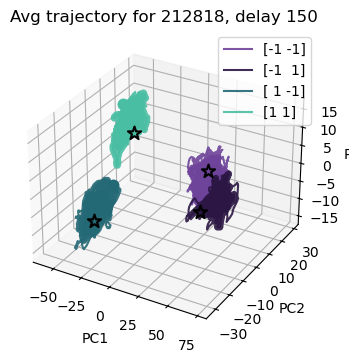

In [ ]:
importlib.reload(pu)

pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=None, title=None,);

(3, 4, 2005) (3, 4, 2005) (3, 4, 2005)
(4, 2005, 3)


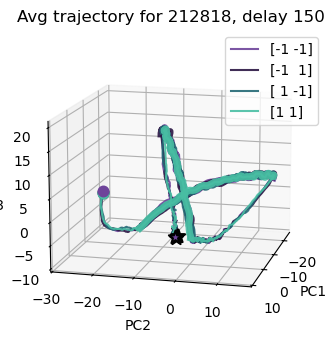

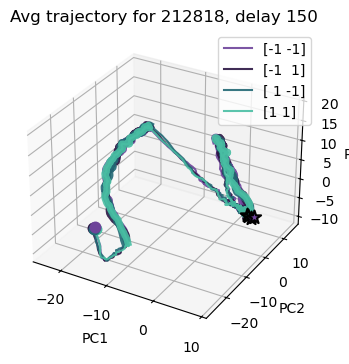

In [16]:
importlib.reload(pu)

%matplotlib inline
pu.plot_trajectory(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   method='dpca',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=None, title=None,);

(3, 4, 2005) (3, 4, 2005) (3, 4, 2005)
(4, 2005, 3)


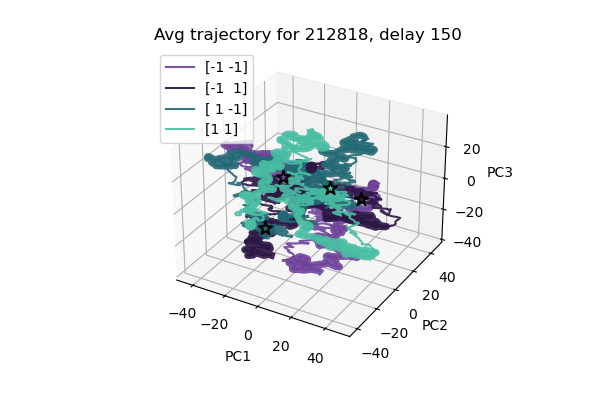

In [19]:
importlib.reload(pu)

%matplotlib ipympl
pu.plot_trajectory(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   method='dpca',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=None, title=None,);

(3, 4, 2005) (3, 4, 2005) (3, 4, 2005)
(4, 2005, 3)
(3, 4, 2005) (3, 4, 2005) (3, 4, 2005)
(4, 2005, 3)
(3, 4, 2005) (3, 4, 2005) (3, 4, 2005)
(4, 2005, 3)


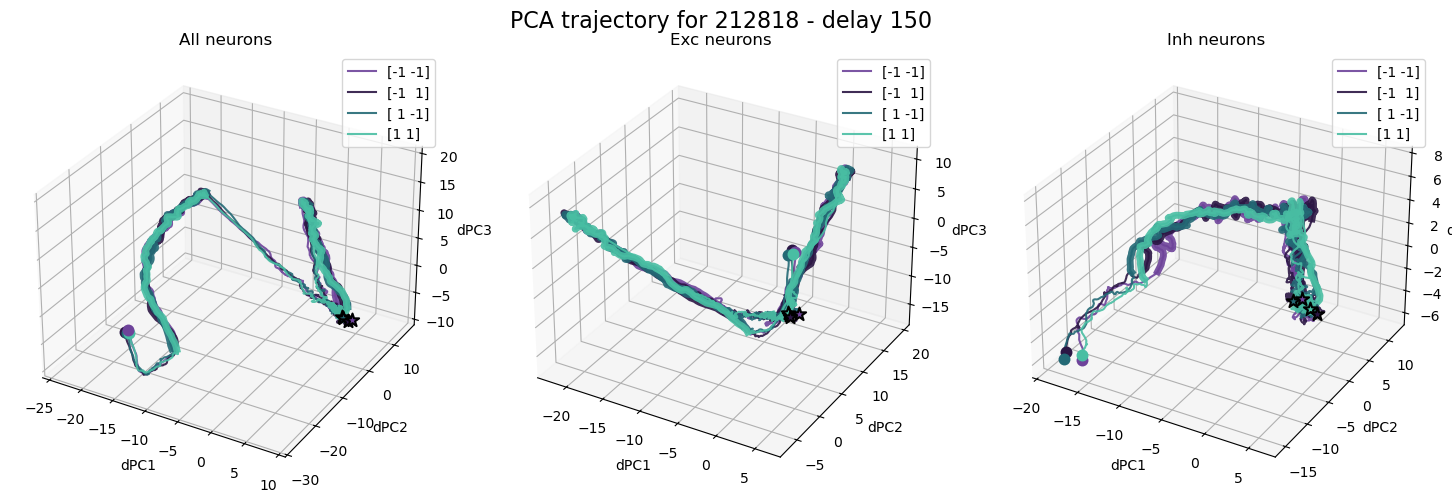

In [22]:
# make 3d plot with 3 subplots
importlib.reload(pu)

%matplotlib inline
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

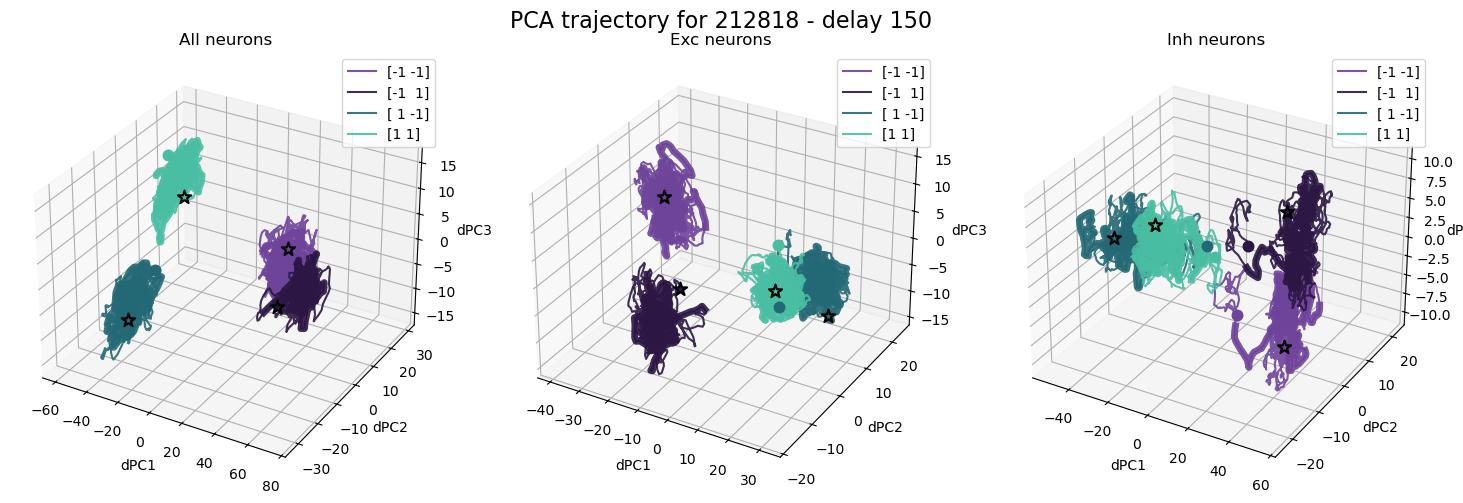

In [23]:
# make 3d plot with 3 subplots
importlib.reload(pu)

%matplotlib inline
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
untuned_idx = np.where(np.isnan(tuning))[0]

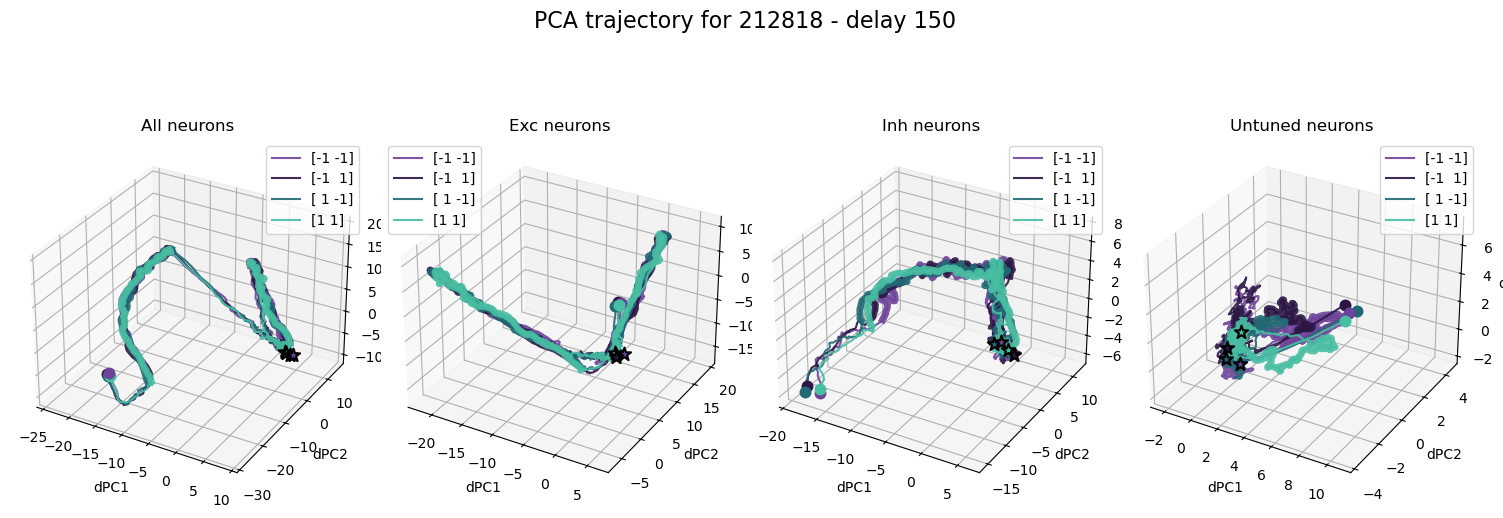

In [25]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

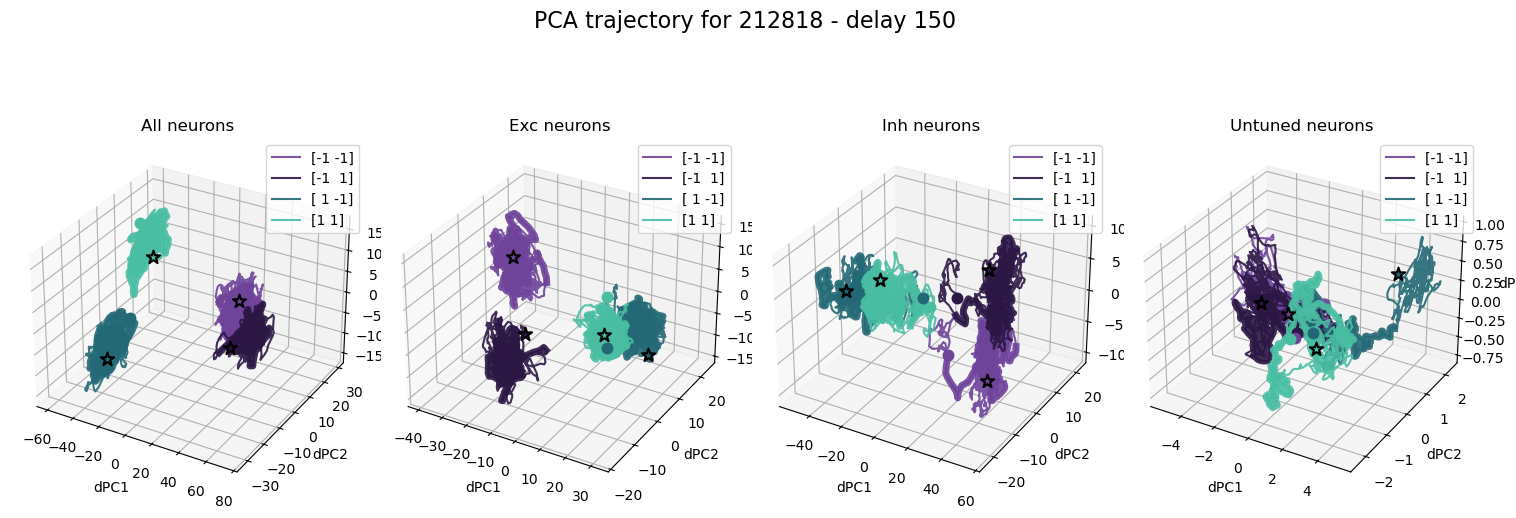

In [26]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

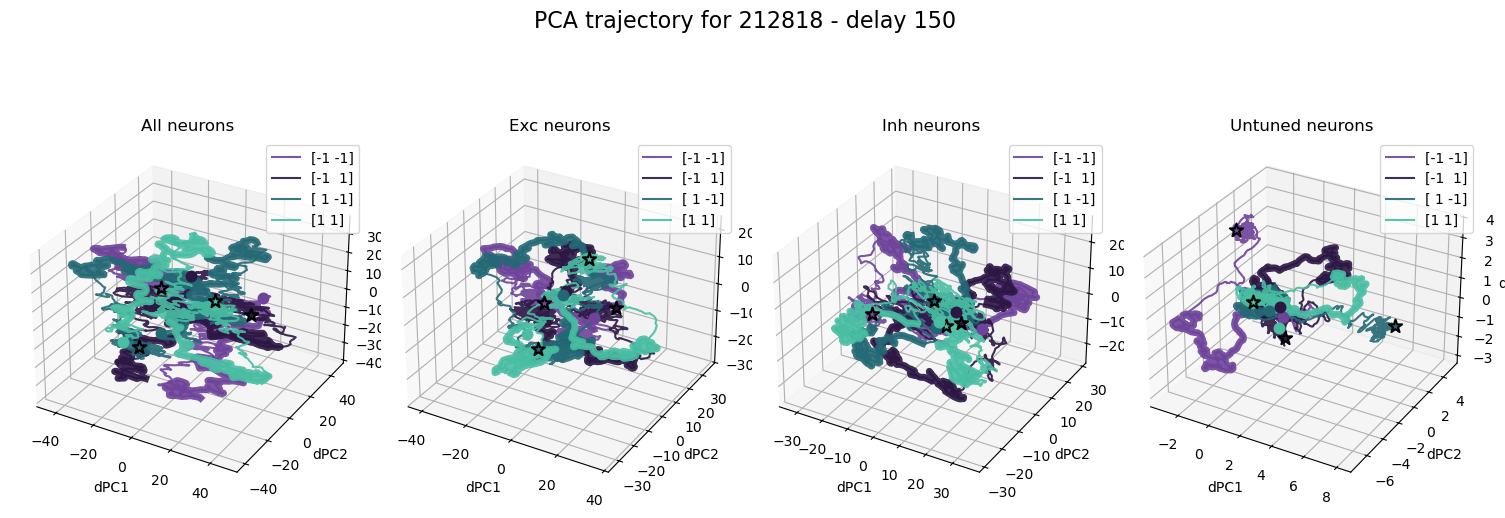

In [27]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='st',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='st',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='st',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='st',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

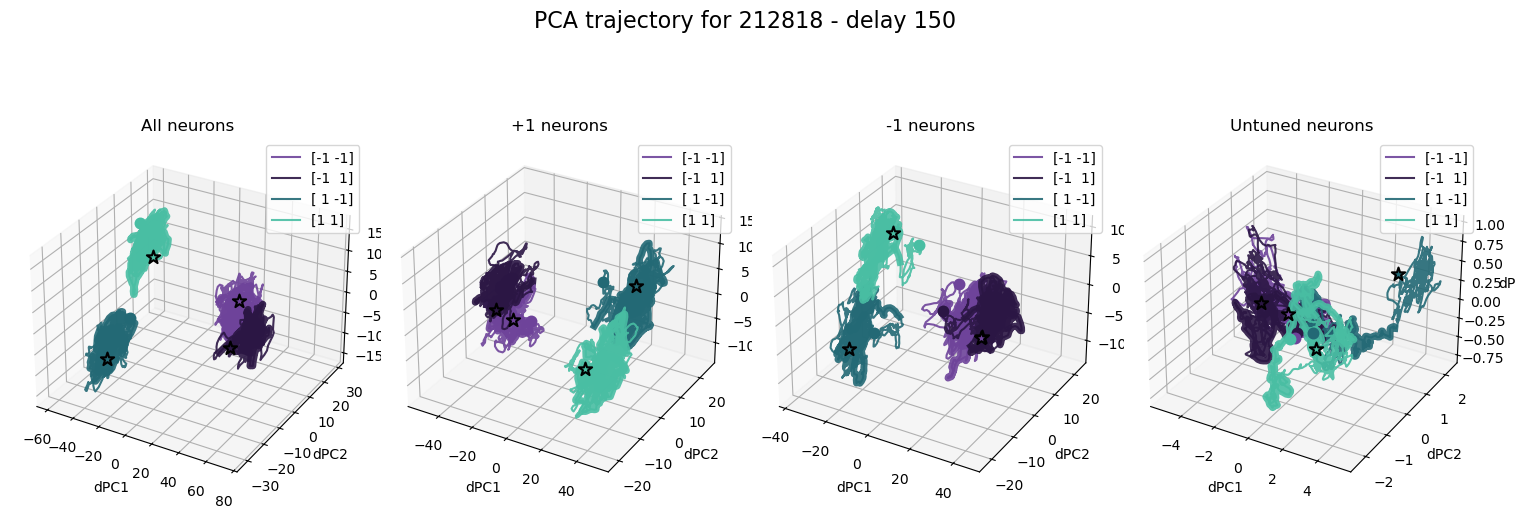

In [28]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='s',
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='s',
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='s',
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

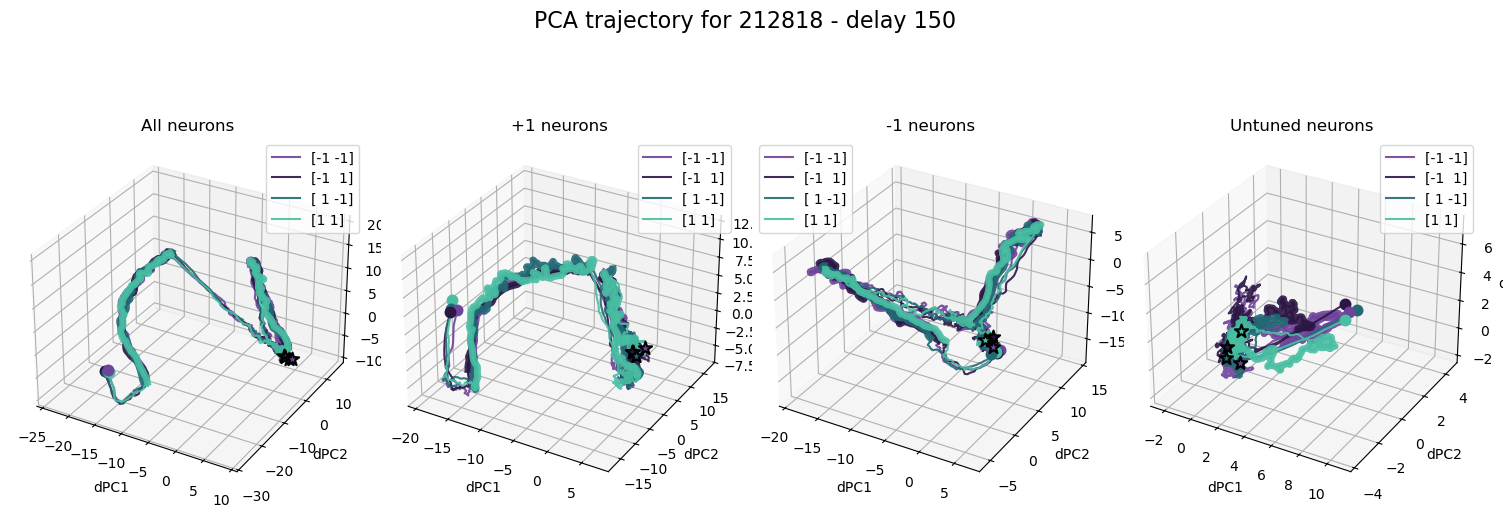

In [ ]:
# Compare trajectories for all neurons, +1 neurons, -1 neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='t',
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
_,_,rates_data_untunedlesion = ld.load_neural_data(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, load_rates=True)

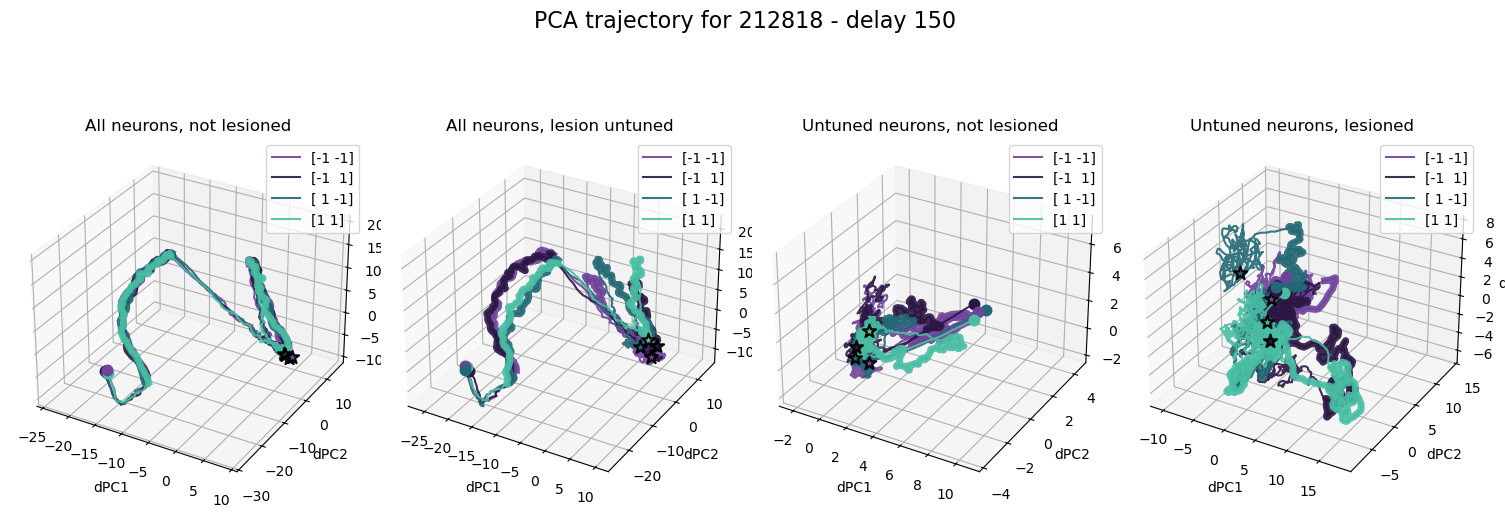

In [11]:
# Compare trajectories for the lesioned and unlesioned models
importlib.reload(pu)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
ax1, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, dpca_obj = dpca_obj_all, plot_type='t',
                   neuron_ids=None, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax2, title='All neurons, lesion untuned')
ax3, dpca_obj_untuned = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax3, title='Untuned neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, dpca_obj = dpca_obj_untuned, plot_type='t',
                   neuron_ids=untuned_idx, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax4, title='Untuned neurons, lesioned',)

plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

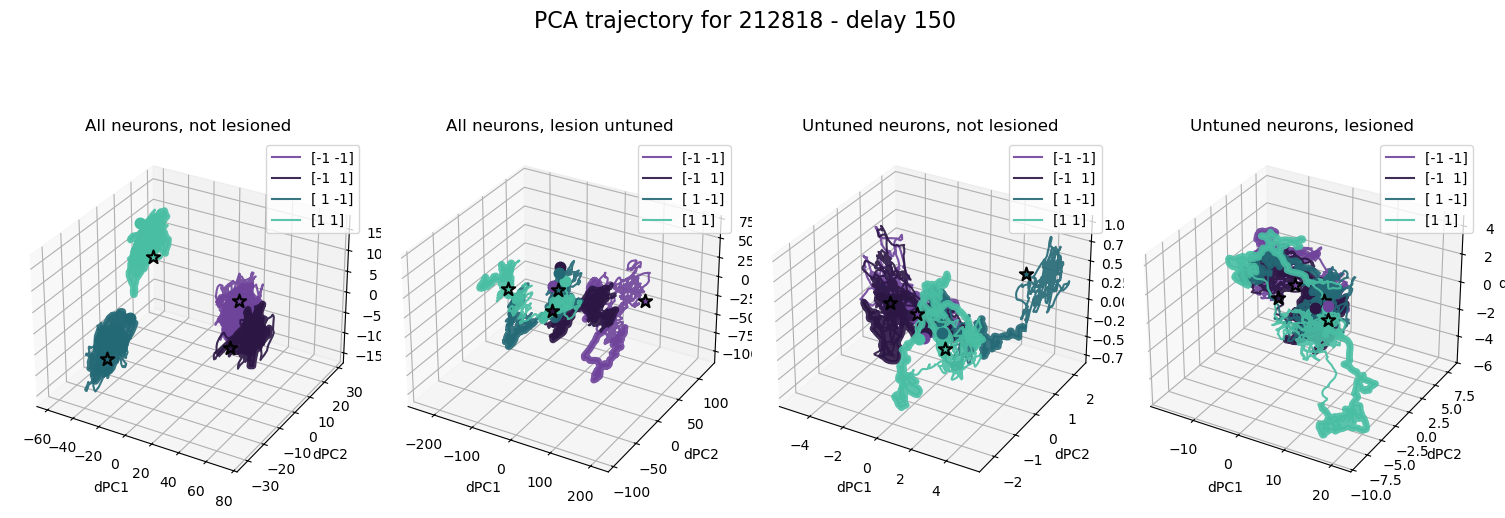

In [12]:
# Compare trajectories for the lesioned and unlesioned models
importlib.reload(pu)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
ax1, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, dpca_obj = dpca_obj_all, plot_type='s',
                   neuron_ids=None, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax2, title='All neurons, lesion untuned')
ax3, dpca_obj_untuned = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax3, title='Untuned neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, dpca_obj = dpca_obj_untuned, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax4, title='Untuned neurons, lesioned',)

plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

#### now the good model that got worse after lesioning

In [13]:
importlib.reload(sn)
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_070855'
print('Loading model: {}'.format(model_name))

_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num, load_rates=True)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
untuned_idx = np.where(np.isnan(tuning))[0]

_,_,rates_data_untunedlesion = ld.load_neural_data(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, load_rates=True)

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_070855


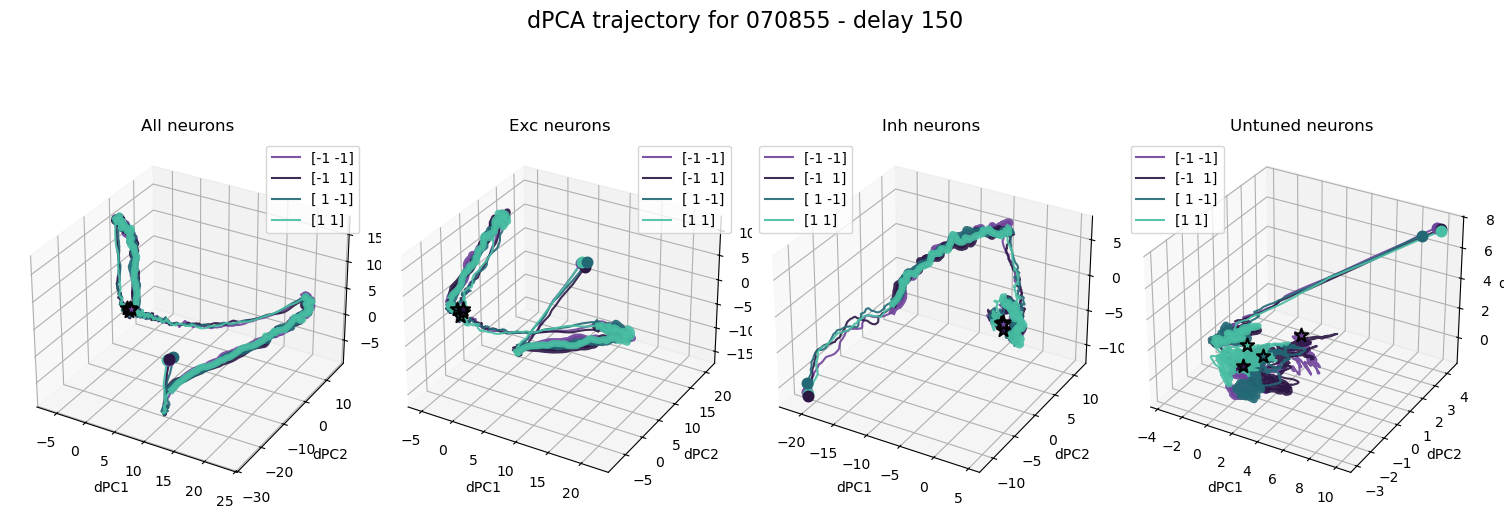

In [14]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

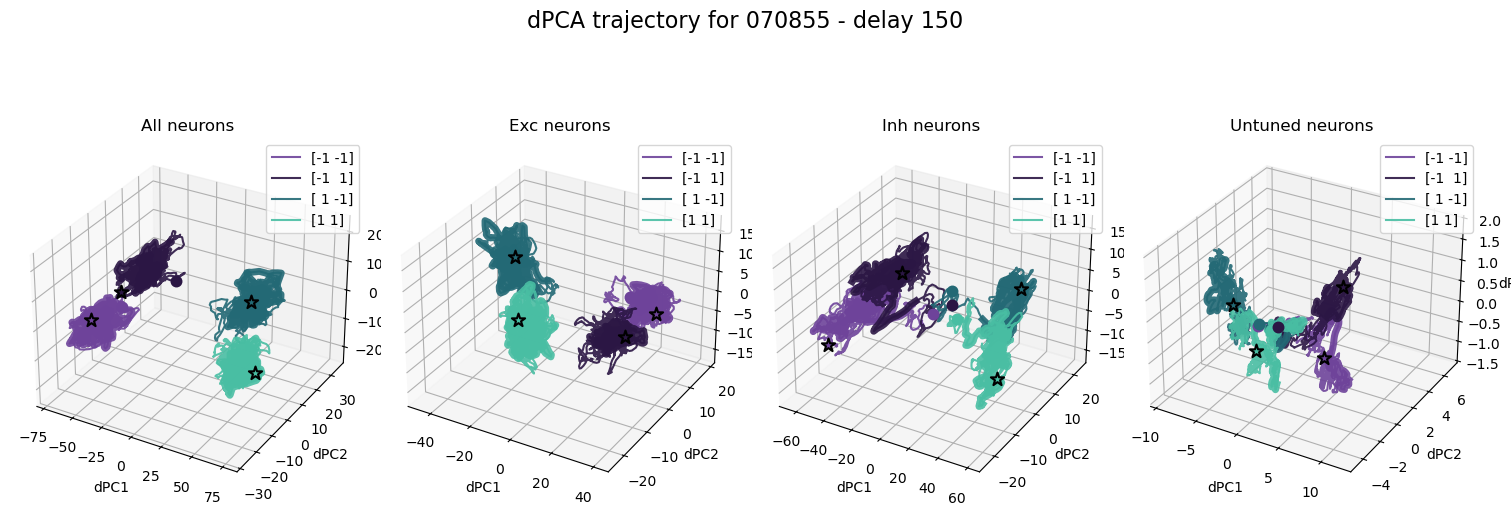

In [15]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

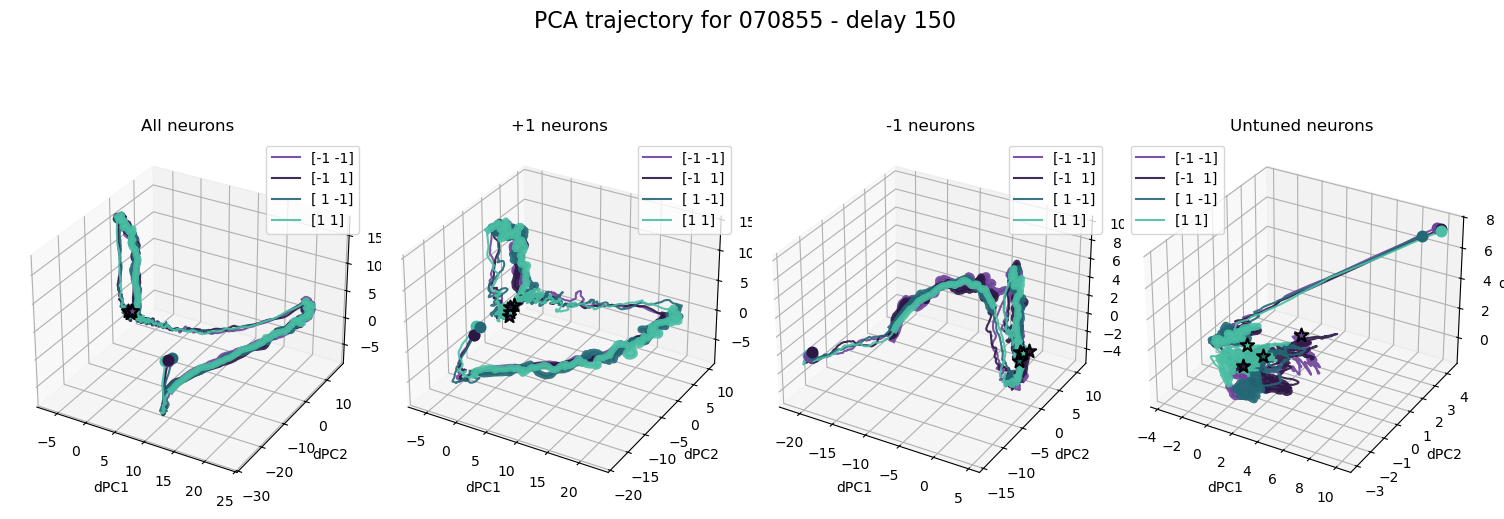

In [16]:
# Compare trajectories for all neurons, +1 neurons, -1 neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='t',
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

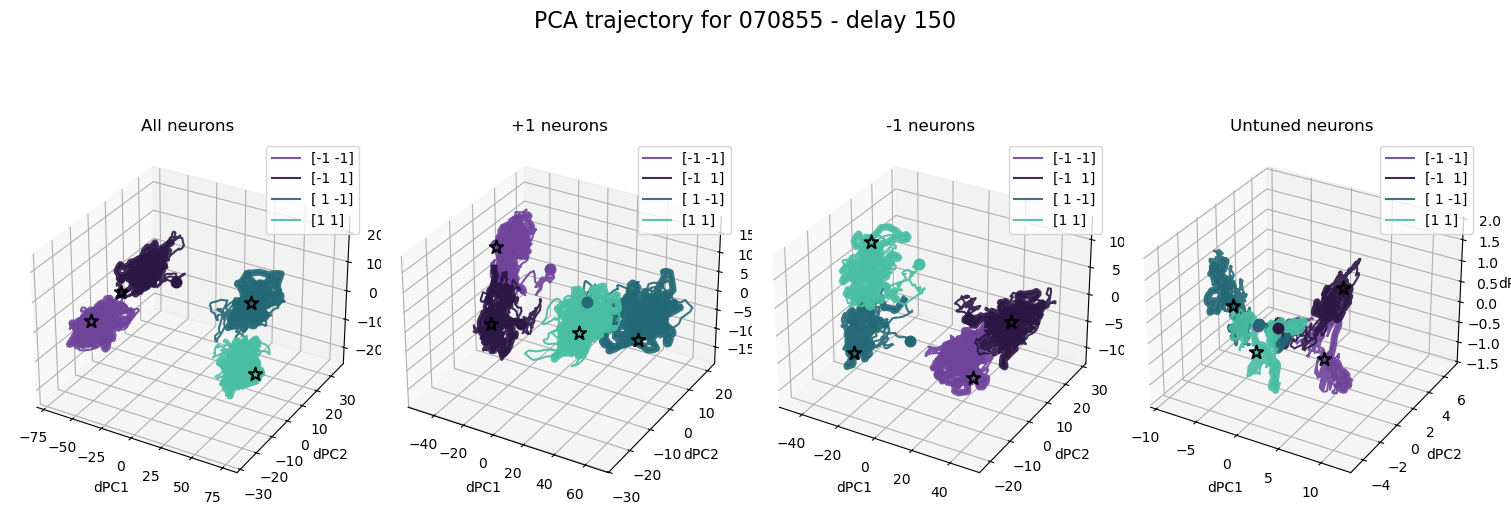

In [17]:
# Compare trajectories for all neurons, +1 neurons, -1 neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

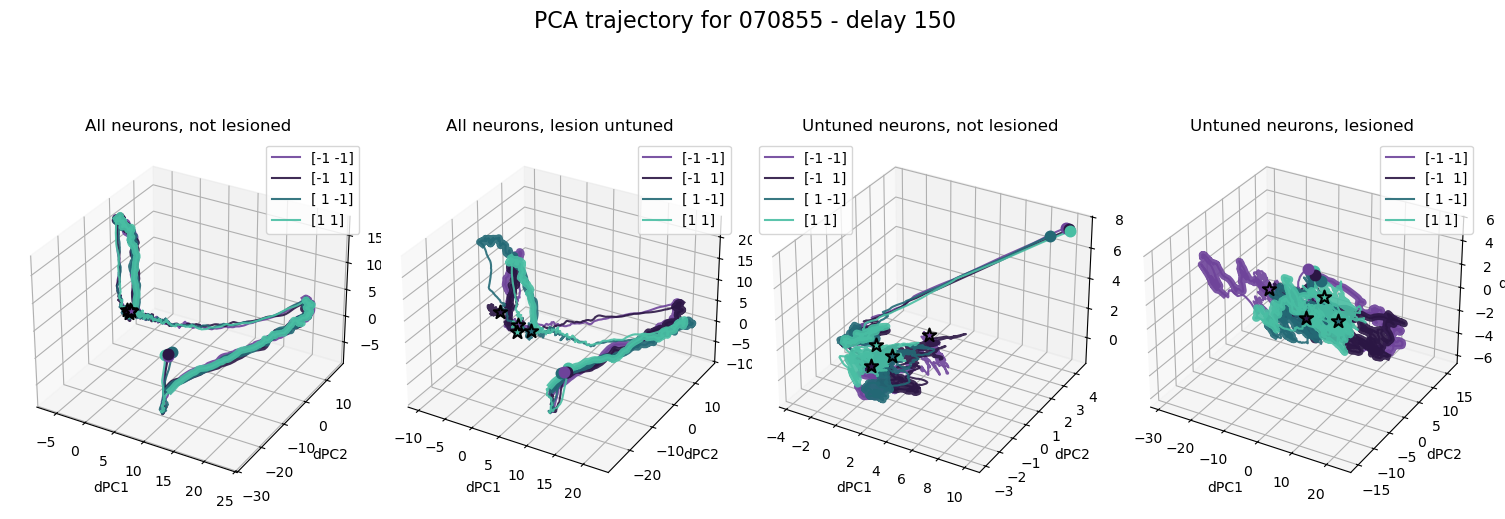

In [18]:
# Compare trajectories for the lesioned and unlesioned models

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
ax1, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, dpca_obj = dpca_obj_all,
                   neuron_ids=None, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax2, title='All neurons, lesion untuned')
ax3, dpca_obj_untuned = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax3, title='Untuned neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, dpca_obj = dpca_obj_untuned,
                   neuron_ids=untuned_idx, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax4, title='Untuned neurons, lesioned',);

plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

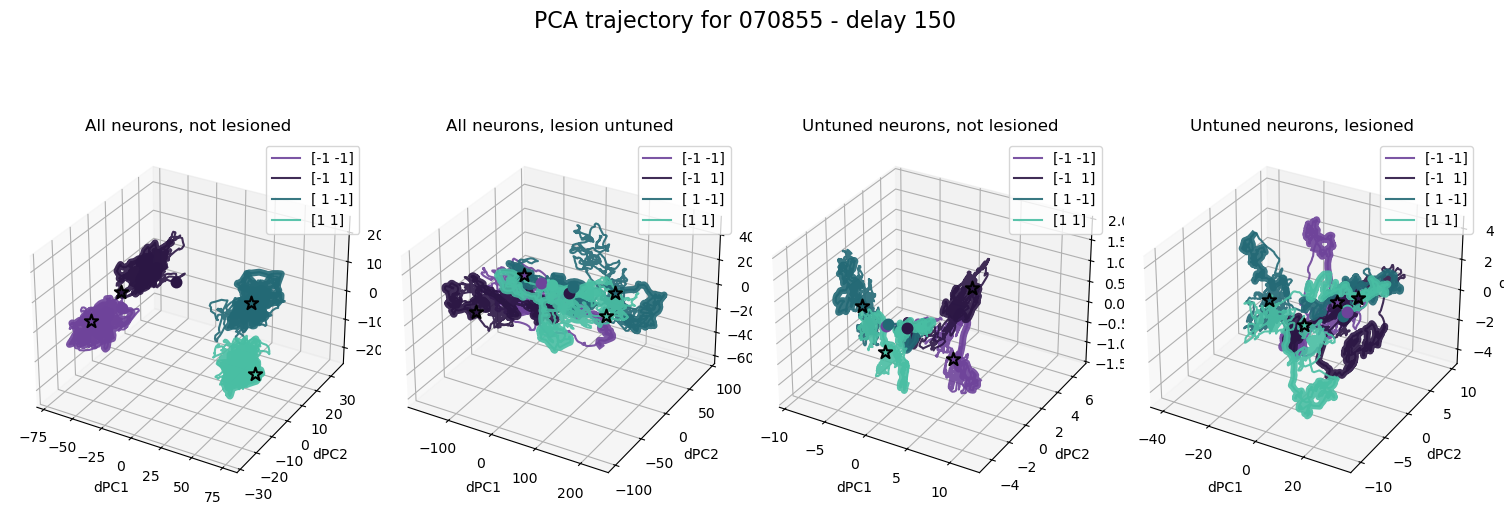

In [19]:
# Compare trajectories for the lesioned and unlesioned models

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
ax1, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, dpca_obj = dpca_obj_all,plot_type='s',
                   neuron_ids=None, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax2, title='All neurons, lesion untuned')
ax3, dpca_obj_untuned = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax3, title='Untuned neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, dpca_obj = dpca_obj_untuned,plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax4, title='Untuned neurons, lesioned',);

plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

### bad models

In [20]:
# get all of the bad models and their performances

bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8, 
                                              condn_phrase=condn_phrase, condn_num=condn_num)

Found 28 models with performance between 0.6 and 0.8


#### bad model that got better after lesioning

In [21]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204500'
print('Loading model: {}'.format(model_name))

_,_,rates_data = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num, load_rates=True)
tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
untuned_idx = np.where(np.isnan(tuning))[0]

_,_,rates_data_untunedlesion = ld.load_neural_data(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, load_rates=True)

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204500


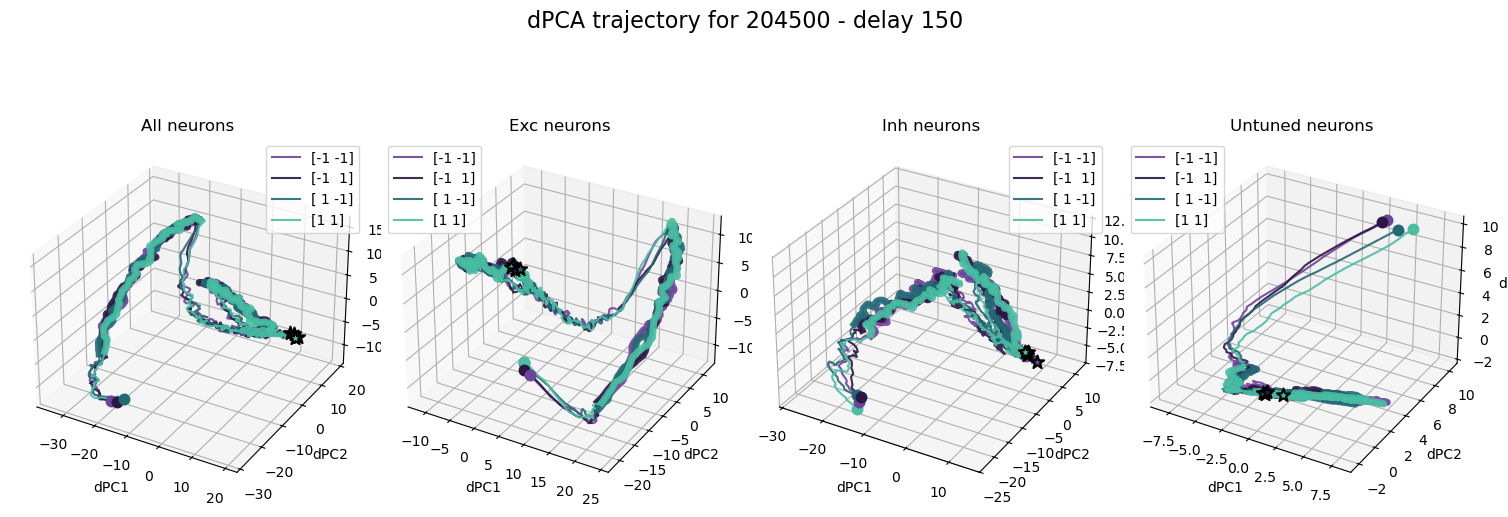

In [22]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

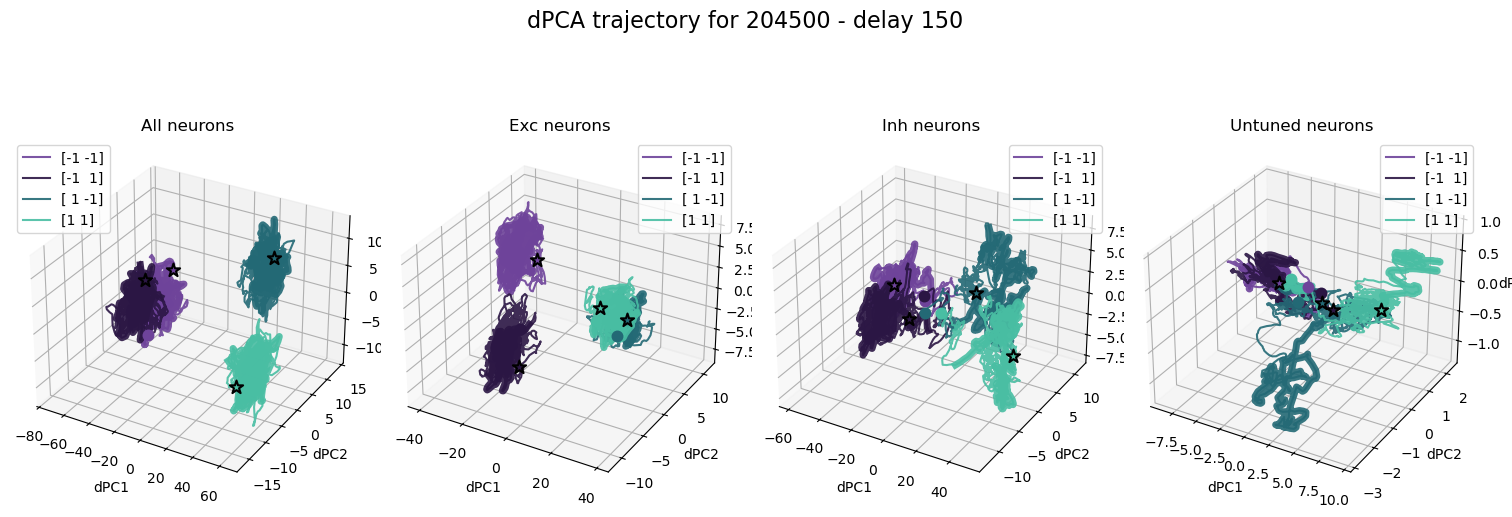

In [23]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=50, ax=ax2, title='Exc neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=50, ax=ax3, title='Inh neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

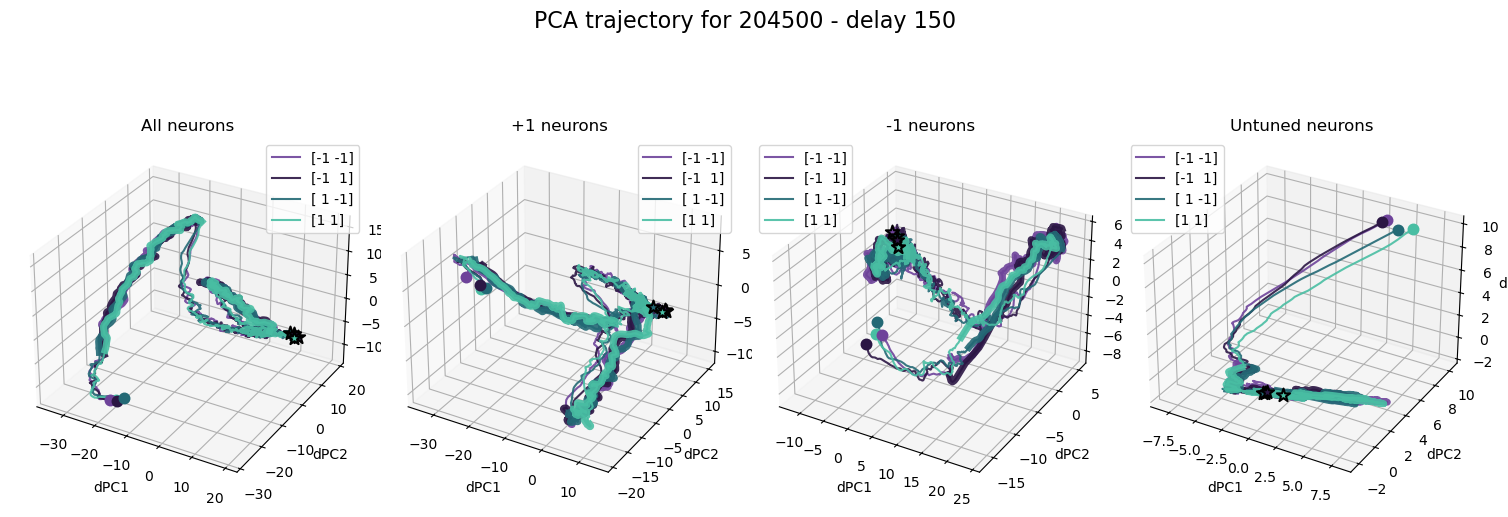

In [24]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

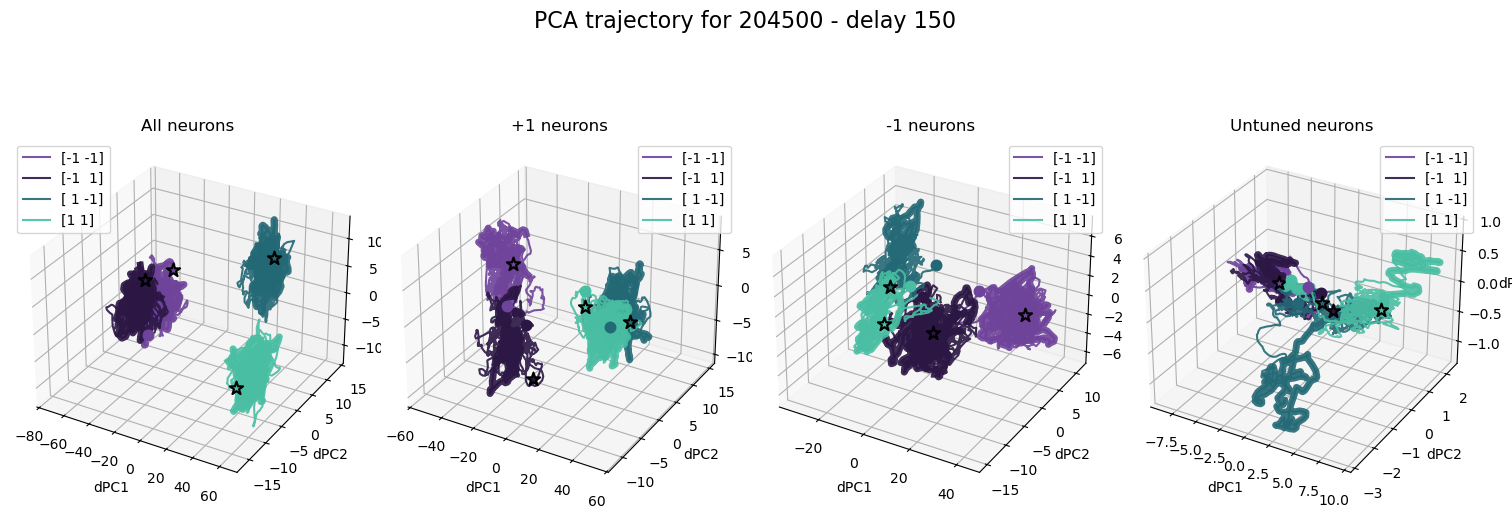

In [25]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

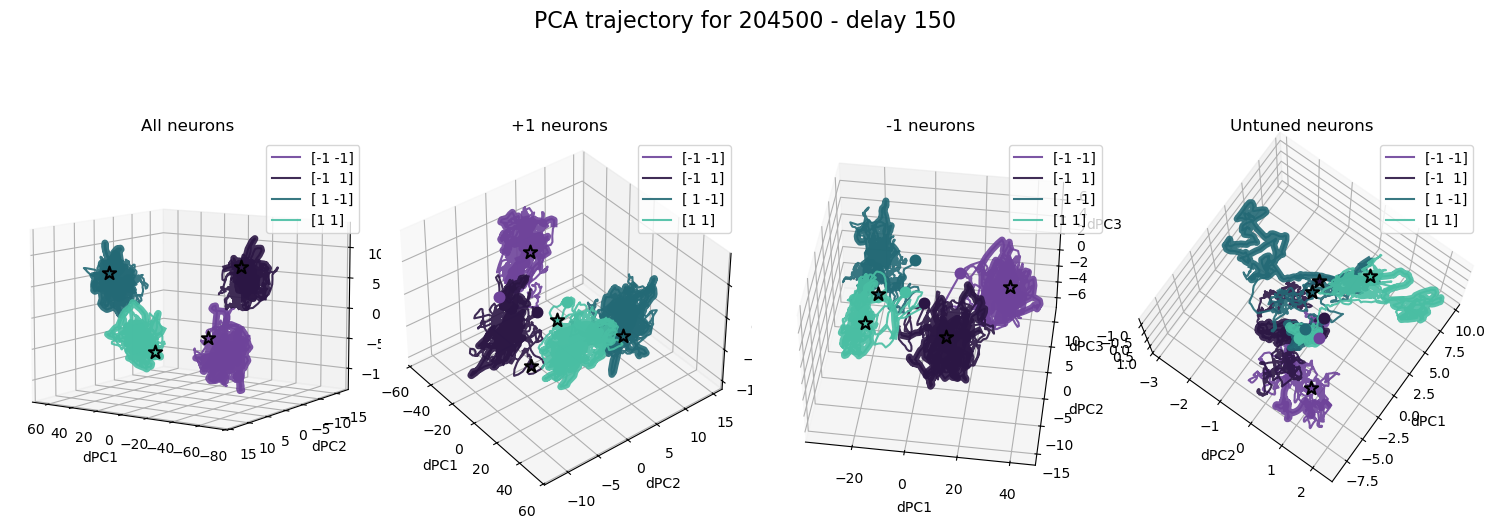

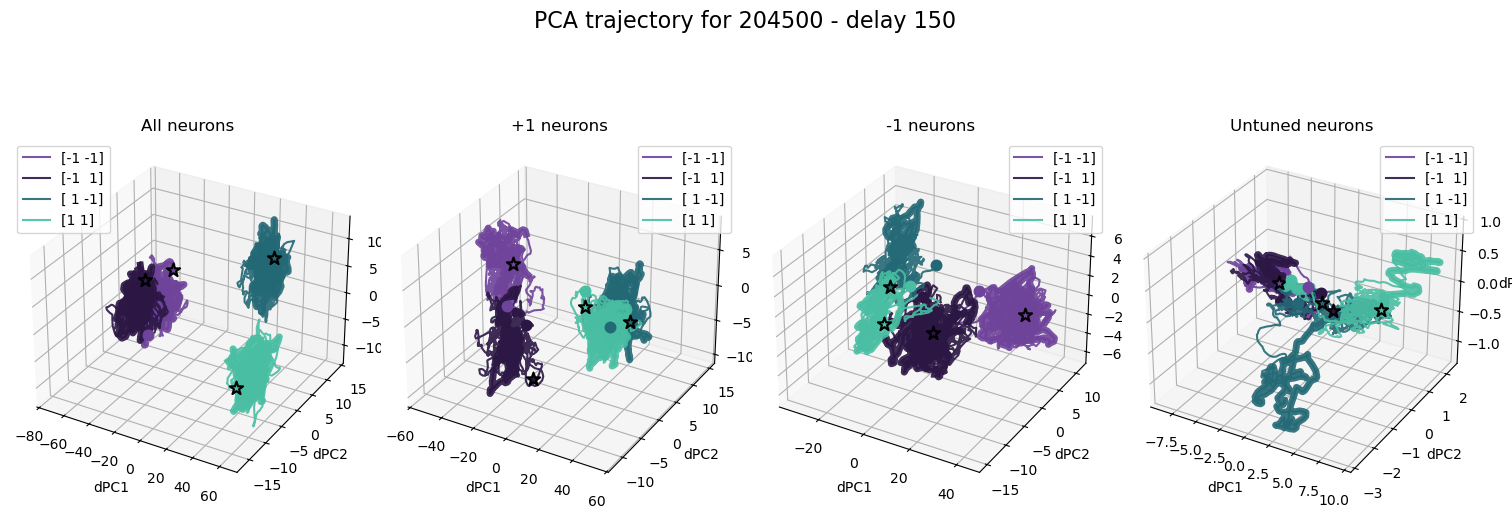

In [30]:
# Compare trajectories for all neurons, exc neurons, inh neurons, and untuned neurons -- not lesioned
%matplotlib inline

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(tuning == 1)[0], rates_data=rates_data, cut_off=50, ax=ax2, title='+1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(tuning == -1)[0], rates_data=rates_data, cut_off=50, ax=ax3, title='-1 neurons')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=np.where(np.isnan(tuning))[0], rates_data=rates_data, cut_off=50, ax=ax4, title='Untuned neurons',);
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

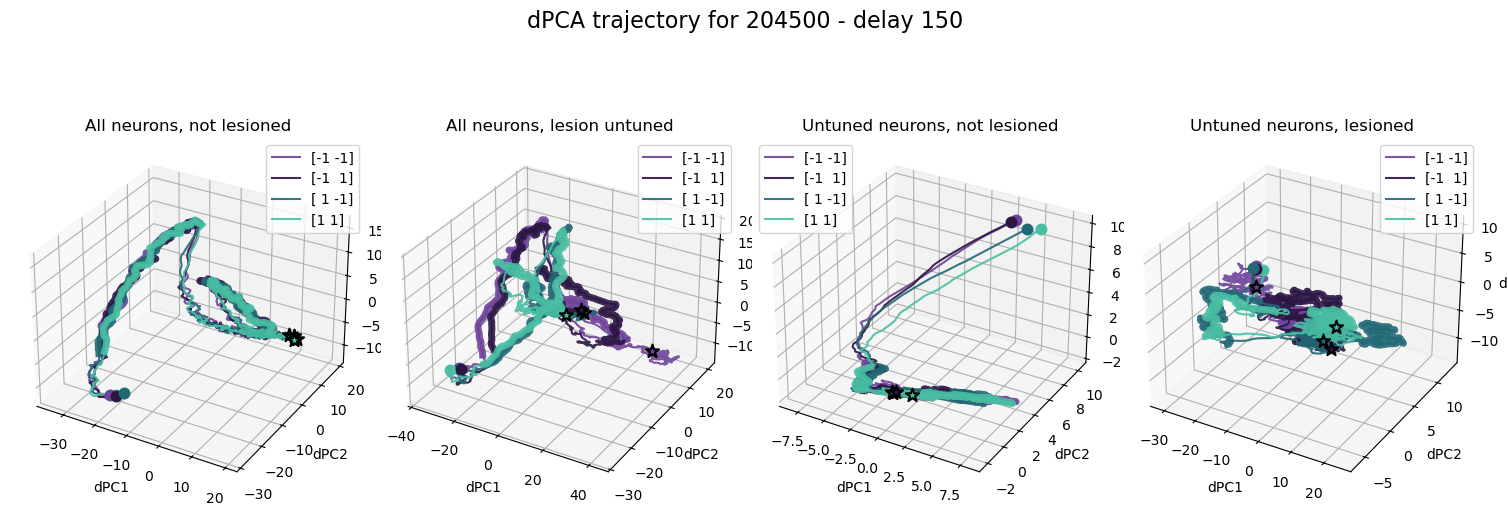

In [27]:
# Compare trajectories for the lesioned and unlesioned models

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
ax1, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, dpca_obj = dpca_obj_all,
                   neuron_ids=None, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax2, title='All neurons, lesion untuned')
ax3, dpca_obj_untuned = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num,
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax3, title='Untuned neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, dpca_obj = dpca_obj_untuned,
                   neuron_ids=untuned_idx, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax4, title='Untuned neurons, lesioned',);

plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

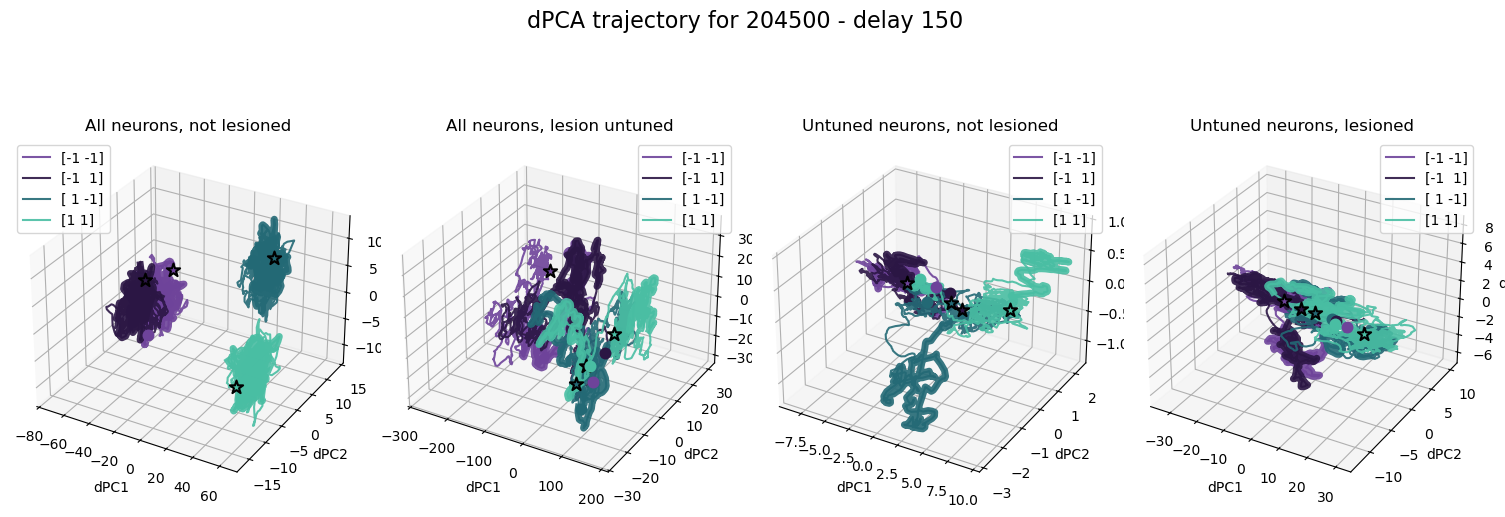

In [28]:
# Compare trajectories for the lesioned and unlesioned models

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')
ax1, dpca_obj_all = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=None, rates_data=rates_data, cut_off=50, ax=ax1, title='All neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase='lesionuntuned_delay', condn_num=condn_num, dpca_obj = dpca_obj_all, plot_type='s',
                   neuron_ids=None, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax2, title='All neurons, lesion untuned')
ax3, dpca_obj_untuned = pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data, cut_off=50, ax=ax3, title='Untuned neurons, not lesioned')
pu.plot_trajectory_dpca(model_name, condn_phrase=condn_phrase, condn_num=condn_num, dpca_obj = dpca_obj_untuned, plot_type='s',
                   neuron_ids=untuned_idx, rates_data=rates_data_untunedlesion, cut_off=50, ax=ax4, title='Untuned neurons, lesioned',);

plt.suptitle(f'dPCA trajectory for {model_name[-6:]} - {condn_phrase} {condn_num}', fontsize=16)
plt.tight_layout()
plt.show()

## anyways